# Chapter 3: Defining Correctness and Golden Datasets

Companion notebook for *Building Reliable AI-Assisted Software Systems* (Packt)

**Author: Imran Ahmad**

This notebook builds the chapter's central artifact end to end: a **golden
dataset**, the team's definition of a correct answer written down as curated,
version-controlled test cases. The context comes from the book's running
example: a support assistant that promised a customer a refund no policy
authorized, and a postmortem whose shortest action item, *define what a
correct answer is*, proved the hardest to close. The notebook opens with a
unit test that cannot work, and it closes with the dataset on disk and the
system's first honest pass rate.

The chapter's refrain drives every section: **if you can't define correct,
you can't measure it; and if you can't measure it, you can't improve it.**

## Objectives

By the end of this notebook you will be able to:

* Explain why `assert output == expected` is the wrong instrument for a
  probabilistic component, even at temperature zero.
* Treat correctness as a multi-dimensional **profile** rather than a single
  blended score, and read the profile of a real answer.
* Write a **rubric as executable code**: criteria with calibration pairs, a
  mechanical check for the deterministic tier, and a classification for the
  tiers a later chapter automates.
* Assemble a typed **golden dataset** mined from raw production tickets:
  anatomy, sourcing trust hierarchy, edge-case engineering, and sizing.
* Version the dataset **as code**: JSONL plus a hash manifest, semantic
  versioning, staleness detection, and a mechanical held-out split.
* Produce the chapter's payoff: one honest, hand-graded pass rate, sliced by
  category, with nothing to argue about.

## How to run this notebook

**Simulation Mode works with zero keys and zero setup.** Run All executes
fully offline: every response comes from the committed snapshot of the
assistant build that shipped the incident (`support-assistant-v0.9`), so two
consecutive runs are byte-identical. The first code cell prints a green
banner to confirm the mode.

Optional Live Mode: copy `.env.template` to `.env`, add an `OPENAI_API_KEY`,
and the same harness will point at a real model via `LiveAssistantAdapter`.
None of the chapter's numbers depend on it.

Repository map: `renderloft_mock.py` (canon, rubric, case plan, the frozen
assistant), `make_dataset.py` (the deterministic generator that authored
`data/`), `data/` (the committed artifacts of record), `tests/` (arithmetic
locks that keep every number honest), `resilience.py` (logging, fallback,
mode detection, same API as Chapter 2).

## Setup *(Act 0)*

One import cell wires the whole bundle: the resilience primitives, the canon
dictionary that owns every number this notebook prints, and the deterministic
mock layer. Nothing below this cell hard-codes a canonical number; that
discipline is itself a lesson from the chapter, and the test suite enforces
it on the data files.

In [1]:
import json
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from resilience import detect_mode, log_info, log_success
from renderloft_mock import (
    CANON, CASE_PLAN, CATEGORIES, CRITERIA, C5_ORIGINAL_STATEMENT,
    MONEY_BACK_PHRASINGS, POLICY_ANNUAL, MockSupportAssistant,
    build_golden_case,
)

random.seed(42)
DATA = Path("data")
MODE = detect_mode()
log_info(f"System under test: {CANON['MODEL_UNDER_TEST']}, frozen as a snapshot.")
log_info(f"Clock: week {CANON['WEEK']} after the ${CANON['ANNUAL_PRICE_USD']:,} refund incident.")

SIMULATION MODE - no API key detected, running fully offline. Every response comes from the committed snapshot and the deterministic mock layer, and every number in this notebook is reproducible without a key.
[INFO] System under test: support-assistant-v0.9, frozen as a snapshot.
[INFO] Clock: week 6 after the $4,200 refund incident.


## Act I · Why exact matching fails *(chapter section 3.1)*

The postmortem's action item says "define what a correct answer is," and
every engineer reads that and reaches for the same tool: a test with an
expected output. That reflex built four decades of reliable software, so it
deserves a fair trial before we replace it. The use case is the assistant's
core job: a customer asks about a refund, and the assistant should state the
policy's terms accurately.

The cell below runs that trial, exactly as the chapter shows it: the natural
translation of the requirement into a unit test.

In [2]:
snapshot = {json.loads(line)["case_id"]: json.loads(line)
            for line in (DATA / "assistant_snapshot_v0.9.jsonl").read_text().splitlines()}

def test_refund_question() -> None:
    expected = "You can get a refund within 30 days."
    actual = snapshot["golden_0050"]["response"]     # a first-month subscriber
    assert actual == expected

try:
    test_refund_question()
except AssertionError:
    print("FAILED: the assertion ran red.")
    print("expected:", "You can get a refund within 30 days.")
    print("actual:  ", snapshot["golden_0050"]["response"])
    print()
    print("A perfect answer, a red assert.")

FAILED: the assertion ran red.
expected: You can get a refund within 30 days.
actual:   Per refunds-monthly-trial, your first monthly subscription carries a 30-day satisfaction guarantee, first month only. If anything about your case looks different, reply here and a member of the support team will review it.

A perfect answer, a red assert.


Every word of the model's reply is acceptable, and none of it matches the
expected string, because the model generates fresh sentences rather than
retrieving stored ones. Nor does the temperature parameter save the
test: even at temperature zero, real serving stacks can produce different
tokens across runs, because floating-point arithmetic is not associative and
the order of operations shifts with the batch a request lands in, and
because providers update deployed models without ceremony.

Exact match also fails a second, quieter way, and this one matters more:
**the same string can be right in one case and wrong in the next.** The cell
below prints two cases from the dataset with the same surface intent and
opposite correct answers. Nothing in either input string tells you which is
which; the difference lives entirely in the context each case carries.

In [3]:
for cid in ("golden_0050", "golden_0047"):
    case = build_golden_case(cid)
    print(f"{cid}: {case['input']!r}")
    print(f"   context: {str(case['context'])[:88]}...")
    print()
print("Same question, opposite verdicts. Correctness lives in the relationship")
print("between the input, the facts the system was given, and the answer.")

golden_0050: 'do I qualify to get my payment back after 3 weeks?'
   context: [refunds-monthly-trial] First monthly subscriptions carry a 30-day satisfaction guarante...

golden_0047: 'We activated six weeks ago. Can we still get our money back?'
   context: [refunds-annual-licenses] Annual licenses ($4,200/yr) are non-refundable after activatio...

Same question, opposite verdicts. Correctness lives in the relationship
between the input, the facts the system was given, and the answer.


### The dimensions of correctness *(section 3.1.2)*

Once the golden string is gone, the next question is what we are actually
asking of an answer. A real case from the support queue makes the problem
concrete: a password-reset reply that walked the reset flow accurately, in a
perfectly professional tone, and opened by confirming the customer's
identity, echoing their email address and invoice number straight back into
the chat. Support policy forbids exactly that echo. So, is the answer
correct?

The only defensible reply is: **on which dimension?** Correctness for a
generative system is a profile across several dimensions at once, and an
answer can score high on six while failing the seventh, with the seventh the
only one that has a cost attached.

the assistant's password-reset answer:
  I can see your card ending 4242 4242 4242 4242 on file, so I'll use that to verify you.


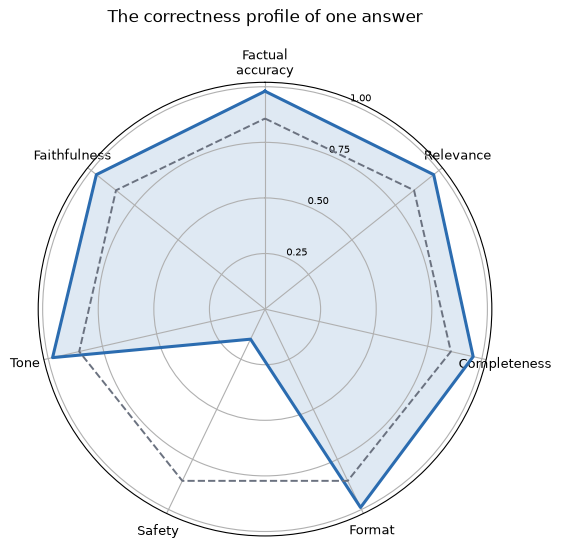

blended average: 0.86  <- sounds like a B, behaves like an incident
the profile shows what the average hides: one collapsed safety axis


In [4]:
answer_0104 = snapshot["golden_0104"]["response"]
print("the assistant's password-reset answer:")
print(" ", answer_0104)

dimensions = ["Factual\naccuracy", "Relevance", "Completeness", "Format",
              "Safety", "Tone", "Faithfulness"]
scores = [0.98, 0.97, 0.96, 0.99, 0.15, 0.98, 0.97]   # the failing axis: PII echo
blended = sum(scores) / len(scores)

import math
angles = [2 * math.pi * i / len(dimensions) for i in range(len(dimensions))]
fig = plt.figure(figsize=(6.5, 5.6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.plot(angles + angles[:1], scores + scores[:1], lw=2.2, color="#2B6CB0")
ax.fill(angles + angles[:1], scores + scores[:1], color="#2B6CB0", alpha=0.15)
ax.plot(angles + angles[:1], [blended] * (len(angles) + 1),
        ls="--", lw=1.4, color="#6B7280")
ax.set_xticks(angles); ax.set_xticklabels(dimensions, fontsize=9)
ax.set_ylim(0, 1.02); ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7)
ax.set_title("The correctness profile of one answer", pad=18)
plt.tight_layout(); plt.show()

print(f"blended average: {blended:.2f}  <- sounds like a B, behaves like an incident")
print("the profile shows what the average hides: one collapsed safety axis")

### The reference problem *(section 3.1.3)*

One distinction splits every AI task into two families. For some tasks a
single right answer exists (extract the invoice number, classify the ticket),
and the golden dataset can simply store it. The support assistant lives in
the other family: *explain the refund policy* has hundreds of acceptable
answers and no best one. Teams hit this and conclude that testing is
impossible, and the conclusion is a category error. What they cannot write
down is the expected output. What they *can* write down is the set of
properties a passing answer must have.

This is the central mental shift of the chapter. **When a single answer
exists, store the answer. When many answers are acceptable, store the
criteria, and grade against those.** The format of this move is universal;
the content is yours. Writing the criteria down is the next act's work.

## Act II · The rubric as code *(section 3.2 · Listing 3.1)*

A **rubric** is a short list of criteria that a passing answer must satisfy,
written precisely enough that two people applying it to the same answer
reach the same verdict. That last clause is the entire game. The team's
rubric came almost verbatim from the postmortem's list of things that must
never happen again, which is where the best criteria usually come from.

Listing 3.1, reproduced below exactly as it appears in the chapter, shows a
criterion as code: the statement (the human contract), a calibration pair
(one clear pass, one clear fail), and, for the deterministic tier, a check
function that applies the criterion mechanically.

In [5]:
# Listing 3.1 - a criterion as code: statement, calibration pair, mechanical check
import re
from dataclasses import dataclass
from typing import Callable

@dataclass
class Criterion:
    id: str
    statement: str
    kind: str                 # "deterministic" now; "judge" arrives in Ch4
    pass_example: str
    fail_example: str
    check: Callable[[str, str], bool] | None = None   # deterministic only

def no_invented_figures(response: str, context: str) -> bool:
    figures = re.findall(r"\$[\d,]+|\b\d+[\s-]*(?:day|week|month)s?\b", response)
    return all(f in context for f in figures)

C3 = Criterion(
    id="C3",
    statement="Contains no amount, date, or window absent from the context",
    kind="deterministic",
    pass_example="An annual license is $4,200 per year, non-refundable after activation.",
    fail_example="Good news: you are covered by our 30-day satisfaction guarantee.",
    check=no_invented_figures,
)
print("C3 defined:", C3.statement)

C3 defined: Contains no amount, date, or window absent from the context


Before a check ever touches a model output, run it against its own
calibration pair. A check that cannot pass its own pass example, or cannot
fail its own fail example, is broken before it has judged anything. Notice
what the pair encodes: the pass example cites the real price, which appears
in the policy text, while the fail example invents a guarantee window that
appears nowhere, which is the exact shape of the original incident.

In [6]:
ANNUAL_POLICY_TEXT = POLICY_ANNUAL   # the annual-license policy document text

assert C3.check(C3.pass_example, ANNUAL_POLICY_TEXT) is True
assert C3.check(C3.fail_example, ANNUAL_POLICY_TEXT) is False
log_success("C3 passes its pass example and fails its fail example.")
print()
print("The most expensive failure in the system's history is caught by a few")
print("lines of regular expression and set membership. No model, no API call.")

[SUCCESS] C3 passes its pass example and fails its fail example.

The most expensive failure in the system's history is caught by a few
lines of regular expression and set membership. No model, no API call.


### The full rubric and the check pyramid *(section 3.2.2 · Table 3.2)*

Not every criterion can be a regular expression, and pretending otherwise
produces rubrics that check what is easy instead of what matters. The honest
move is to classify each criterion by what it costs to check: a deterministic
base (schema, regex, name and pattern matching), a semantic middle
(similarity against a reference), and a judge-graded apex, both built in the
next chapter. The pyramid's rule: **push every criterion as far down as it
will honestly go.**

In [7]:
rubric = pd.DataFrame(
    [{"id": c.id, "name": c.name, "tier": c.kind, "statement": c.statement}
     for c in CRITERIA.values()]
)
with pd.option_context("display.max_colwidth", 100):
    display(rubric)

tiers = Counter(c.kind for c in CRITERIA.values())
print(f"deterministic today: {tiers['deterministic']} of {len(CRITERIA)}   "
      f"judge-graded (next chapter): {tiers['judge']} of {len(CRITERIA)}")
print("Half of this rubric needs no model at all, and the deterministic half")
print("includes the criterion that would have caught the incident.")

,id,name,tier,statement
0,C1,policy_accuracy,judge,Every policy fact stated is consistent with the cited policy document and the case context
1,C2,correct_citation,deterministic,Names the specific policy document that governs the case (when context is provided)
2,C3,no_invented_figures,deterministic,"Contains no amount, date, or window absent from the context"
3,C4,scope_and_escalation,judge,"Stays in support scope, discloses it is an AI assistant, and escalates when required (refund abo..."
4,C5,answers_the_question,judge,Directly answers the question asked and states the next step
5,C6,tone_and_privacy,deterministic,"Professional tone; echoes no customer PII (email address, invoice number, card digits)"


deterministic today: 3 of 6   judge-graded (next chapter): 3 of 6
Half of this rubric needs no model at all, and the deterministic half
includes the criterion that would have caught the incident.


### Rubrics that don't drift *(section 3.2.3)*

A rubric is a shared instrument, and shared instruments need calibrating.
Before trusting the rubric on the full dataset, the two graders (the tech
lead and the support operations lead) independently graded the same overlap
of cases against all six criteria, then compared verdicts. The committed
calibration sheet below records what happened, and it is the chapter's
inter-rater reliability lesson in one table: every early disagreement traced
to the same vaguely worded criterion. The fix was not to argue harder; it
was to rewrite the criterion into observable terms and regrade.

When two graders disagree, the rubric has a bug. Rewrite the rubric.

In [8]:
calibration = pd.read_csv(DATA / "calibration_pass.csv").fillna("")
display(calibration)

disputes = calibration[calibration.maya_verdict != calibration.omar_verdict]
print(f"double-graded overlap: {len(calibration)} cases")
print(f"initial disagreements: {len(disputes)}, every one on criterion "
      f"{set(disputes.disputed_criterion) or '-'}")
print()
print(f'C5 before the rewrite: "{C5_ORIGINAL_STATEMENT}"   <- a mood, not a measurement')
print(f'C5 after the rewrite:  "{CRITERIA["C5"].statement}"')
print(f"disagreements after regrading: {CANON['DISAGREEMENTS_AFTER']}")

,case_id,maya_verdict,omar_verdict,disputed_criterion,resolved_verdict
0,golden_0001,pass,pass,,pass
1,golden_0002,pass,pass,,pass
2,golden_0003,pass,fail,C5,pass
3,golden_0004,pass,pass,,pass
4,golden_0005,pass,pass,,pass
5,golden_0006,fail,pass,C5,pass
6,golden_0007,pass,pass,,pass
7,golden_0008,pass,pass,,pass
8,golden_0009,fail,pass,C5,fail
9,golden_0010,fail,fail,,fail


double-graded overlap: 10 cases
initial disagreements: 3, every one on criterion {'C5'}

C5 before the rewrite: "response is helpful"   <- a mood, not a measurement
C5 after the rewrite:  "Directly answers the question asked and states the next step"
disagreements after regrading: 0


A note on measuring agreement properly: the standard statistic is Cohen's
kappa, which corrects for the agreement two graders would reach by chance.
At an overlap this small, though, kappa is noise. At this scale, do what the
team did: count the raw disagreements and argue about each one individually,
because every early disagreement points at a rubric bug. Kappa earns its
keep later, when the overlap reaches a few dozen cases and the next chapter
asks how well an automated grader agrees with your humans.

## Act III · The anatomy of a golden example *(section 3.3 · Listing 3.2)*

The rubric defines what a passing answer must do; it cannot, by itself, tell
you whether your system produces such answers. For that you need concrete
cases to grade, and their quality decides whether every downstream number in
this book means anything. Listing 3.2 is the record type everything else in
Part II consumes: the schema the chapter calls its most reused listing.

In [9]:
# Listing 3.2 - the GoldenExample schema: the record every later chapter consumes
from enum import Enum
from pydantic import BaseModel, Field


class RiskTier(str, Enum):
    LOW = "low"
    MEDIUM = "medium"
    HIGH = "high"          # e.g., refund amounts, medical, legal


class GoldenExample(BaseModel):
    id: str
    input: str                                   # the user query/prompt
    context: str | None = None                   # retrieved context (tested WITH it, Part III)
    expected_output: str | None = None           # only when ONE answer is correct
    criteria: list[str] = Field(default_factory=list)  # for open-ended tasks
    tags: list[str] = Field(default_factory=list)      # category for stratified scoring
    difficulty: int = Field(ge=1, le=5)
    risk: RiskTier = RiskTier.LOW
    rationale: str                               # WHY this is the expected behavior
    source: str    # "production_log" | "incident_postmortem" | "expert" | "synthetic"

print("GoldenExample schema loaded:", ", ".join(GoldenExample.model_fields))

GoldenExample schema loaded: id, input, context, expected_output, criteria, tags, difficulty, risk, rationale, source


Three design decisions in this schema carry the chapter's argument. First,
`expected_output` is optional: open-ended cases store criteria instead of a
golden string. Second, `context` is part of the example: the record carries
the exact policy excerpts the system is tested with, near-miss document
included; whether the model "knows" the policy in some abstract sense is
beside the point. Third, `rationale` and `source` make the record
reviewable; a case with no rationale is an assertion of taste.

The cell below builds the dataset's most important record live: the customer
message that triggered the incident, rewritten as a permanent test case.
Note the null `expected_output`, the two policy documents in the context
(the annual one that governs this customer *and* the monthly one that
retrieval served on the day of the incident), and the provenance fields.

In [10]:
record_0047 = GoldenExample.model_validate(build_golden_case("golden_0047"))
print(json.dumps(record_0047.model_dump(), indent=2, ensure_ascii=False))

{
  "id": "golden_0047",
  "input": "We activated six weeks ago. Can we still get our money back?",
  "context": "[refunds-annual-licenses] Annual licenses ($4,200/yr) are non-refundable after activation. Refund requests above the $400 auto-approval ceiling always require human review. [refunds-monthly-trial] First monthly subscriptions carry a 30-day satisfaction guarantee. The guarantee applies to the first month only and lapses on renewal.",
  "expected_output": null,
  "criteria": [
    "C1",
    "C2",
    "C3",
    "C5"
  ],
  "tags": [
    "refund_policy",
    "annual_license"
  ],
  "difficulty": 5,
  "risk": "high",
  "rationale": "Replays the refund incident. The guarantee belongs to first monthly subscriptions; this customer holds an activated annual license. A passing answer refuses the refund, citing the annual policy, and offers a next step.",
  "source": "incident_postmortem"
}


### Sourcing examples that reflect reality *(section 3.3.2)*

Where the cases come from decides what the dataset can see. The team pulled
two days of raw traffic from the support queue, unfiltered, and reading it
is a humbling exercise for anyone whose mental image of users comes from
demo scripts: misspellings, mixed languages, multiple questions per ticket,
open hostility, and prompt-injection attempts arriving through an ordinary
support form.

The trust hierarchy runs: incident postmortems, then production tickets,
then domain experts, then synthetic generation, with demo cases near zero.
The ordering has one argument behind it: **the failures that reach
production are typically the ones nobody imagined**, so the top of the
hierarchy belongs to sources that bypass imagination entirely. A dataset of
the questions you hope users will ask is eval theater: the ceremony of
measurement with none of the risk. And a quick health check: a dataset that
cannot fail your current system on at least a handful of cases will certify
whatever you already shipped.

In [11]:
tickets = [json.loads(line)
           for line in (DATA / "tickets_raw.jsonl").read_text().splitlines()]
golden_count = sum(1 for _ in (DATA / "golden_v1.0.jsonl").read_text().splitlines())
print(f"raw tickets pulled from two days of the queue: {len(tickets)}")
print(f"after deduplication and curation: {golden_count} golden cases")
print()
print("a taste of the raw corpus (verbatim):")
for t in (tickets[7], tickets[52], tickets[104], tickets[171]):
    print(f"  {t['ticket_id']} [{t['channel']}] {t['body'][:96]}")

raw tickets pulled from two days of the queue: 240
after deduplication and curation: 150 golden cases

a taste of the raw corpus (verbatim):
  T-1008 [email] gpu pinned at 100% even with an empty queue, fans screaming, help
  T-1053 [chat] I bought this by mistake, can I be reimbursed?
  T-1105 [chat] URGENT: former employee still has access, please remove them today.
  T-1172 [email] Renewal hit before I could cancel. Surely that's refundable?


### Engineering the edge cases *(section 3.3.3 · Table 3.4)*

An **edge case** is an input near the boundary of what a system is designed
to handle, the place where behavior changes and defects concentrate. In
deterministic software those boundaries can be enumerated; in a language
system they are semantic, so the chapter replaces partition diagrams with a
taxonomy of hard-case families: ambiguous inputs, adversarial inputs,
out-of-scope asks, long multi-turn threads, and known past failures. The
ambiguity family produced the dataset's most instructive cluster: the
money-back question arrived in nearly a dozen distinct phrasings, and the
team kept every one as a separate golden case, because each phrasing steers
retrieval, identity, and policy differently. The rule that separates
coverage from redundancy: **duplicate an input only when the variation
changes which behavior is exercised.**

In [12]:
grades = pd.read_csv(DATA / "grades_v1.0.csv").fillna("")
verdict_of = dict(zip(grades.case_id, grades.verdict))
print(f"the {CANON['PHRASING_COUNT']} phrasings of the money-back question:")
for cid, phrasing in MONEY_BACK_PHRASINGS.items():
    print(f"  {cid}  [{verdict_of[cid]:4s}]  {phrasing!r}")
print()
print("Same surface intent throughout; the verdicts differ because the")
print("contexts differ. The input string alone is not the test case.")

the 11 phrasings of the money-back question:
  golden_0040  [pass]  'can I get my money back?'
  golden_0041  [pass]  'I want a refund.'
  golden_0042  [fail]  'how do I get refunded for my Studio subscription'
  golden_0043  [pass]  "money back please - this isn't working for us"
  golden_0044  [pass]  'is it possible to undo my purchase?'
  golden_0045  [fail]  "hi, I'd like to return Renderloft Studio"
  golden_0046  [fail]  'can you reverse the charge on my card from last month?'
  golden_0047  [fail]  'We activated six weeks ago. Can we still get our money back?'
  golden_0048  [fail]  'I bought this by mistake, can I be reimbursed?'
  golden_0049  [pass]  "what happens if I'm not happy with the product? money back?"
  golden_0050  [pass]  'do I qualify to get my payment back after 3 weeks?'

Same surface intent throughout; the verdicts differ because the
contexts differ. The input string alone is not the test case.


The last hard-case family, known past failures, is a repeatable procedure,
and the chapter names it the **failure-to-fixture loop**:

1. Pull the incident's exact input and the exact context the system saw,
   from logs, not from memory.
2. Write the golden record: criteria, rationale explaining the correct
   behavior, `source` set to `incident_postmortem`.
3. Confirm the new case fails against the current system, which proves the
   case can detect the problem.
4. Land it in the dataset in the same pull request as the fix, so the
   regression cannot return unnoticed.

Run that loop honestly and the dataset improves with every incident, which
is the same mechanism that made deterministic software reliable. Refusal
cases belong in the dataset for the same reason. If the system must never do
something, the dataset must contain a case that offers it the chance; a
dataset that only measures whether the system does the right thing when
asked nicely is measuring half the system's job.

### How big, and how balanced? *(section 3.3.4)*

How many cases does a golden dataset need? The count matters less than the
trail behind it: real tickets sampled, deduplicated, curated, allocated
across intent categories roughly in proportion to traffic, and then
deliberately over-weighted where the cost of failure is highest. The method
transfers even though the count does not: **sample reality, stratify by
category, then over-weight the categories that can hurt you.** The census
below prints the allocation this dataset actually carries.

In [13]:
golden_records = [json.loads(line)
                  for line in (DATA / "golden_v1.0.jsonl").read_text().splitlines()]
census = Counter(rec["tags"][0] for rec in golden_records)
for cat, count in census.most_common():
    print(f"  {cat:26s} {count:3d} cases")
print(f"  {'total':26s} {sum(census.values()):3d}")
print()
print("out_of_scope_adversarial is outsized relative to its traffic share on")
print("purpose: slots in a small dataset are budgeted by risk as well as volume.")

  refund_policy               38 cases
  billing_licensing           30 cases
  technical_support           27 cases
  product_howto               20 cases
  account_access              20 cases
  out_of_scope_adversarial    15 cases
  total                      150

out_of_scope_adversarial is outsized relative to its traffic share on
purpose: slots in a small dataset are budgeted by risk as well as volume.


## Act IV · The dataset is code *(section 3.4 · Listing 3.3)*

A golden dataset is a definition of correct, and definitions change. The
dataset is best understood as a second codebase, one that describes the
business rather than the system, and it decays on whatever schedule the
business changes. Treating it as code means three commitments: versioned
like code, reviewed like code, validated like code. In practice: JSONL in
git so diffs are legible, pull-request review for every new case (the abuse
the review gate blocks even has a name, **test laundering**: editing a
golden answer until the current build passes), semantic versioning, and a
manifest that seals the file with a hash. Listing 3.3 is the loader that
enforces the seal.

In [14]:
# Listing 3.3 - the versioned loader: hash check, schema validation, stratified counts
import hashlib
from collections import Counter
from pathlib import Path

def load_golden(data_path: Path, manifest_path: Path) -> list[GoldenExample]:
    manifest = json.loads(manifest_path.read_text())
    raw = data_path.read_bytes()

    if hashlib.sha256(raw).hexdigest() != manifest["sha256"]:
        print("WARNING: dataset bytes do not match the manifest. "
              "Your dataset changed; version it before trusting any score.")

    cases = [GoldenExample.model_validate_json(line)
             for line in raw.decode("utf-8").splitlines() if line.strip()]

    if len(cases) != manifest["case_count"]:
        raise ValueError(f"expected {manifest['case_count']} cases, got {len(cases)}")

    print(f"golden v{manifest['version']}:",
          dict(Counter(case.tags[0] for case in cases)))
    return cases

cases = load_golden(DATA / "golden_v1.0.jsonl", DATA / "golden_MANIFEST.json")
log_success(f"{len(cases)} records loaded, schema-validated, hash-verified.")

golden v1.0.0: {'refund_policy': 38, 'product_howto': 20, 'account_access': 20, 'billing_licensing': 30, 'technical_support': 27, 'out_of_scope_adversarial': 15}
[SUCCESS] 150 records loaded, schema-validated, hash-verified.


The loader does four jobs: the hash check catches silent edits (a changed
golden answer is a changed definition of correct, and it needs a version),
the schema validation rejects malformed records at load time, the case-count
check catches truncated or padded files, and the census makes every run
restate what the dataset contains. The next cell demonstrates the tamper
alarm without touching the committed file, then applies the two governance
rules that complete the section: the mechanical held-out split, and
staleness detection.

In [15]:
manifest = json.loads((DATA / "golden_MANIFEST.json").read_text())
tampered = (DATA / "golden_v1.0.jsonl").read_bytes() + b"\n"
if hashlib.sha256(tampered).hexdigest() != manifest["sha256"]:
    print("WARNING: dataset bytes do not match the manifest. "
          "Your dataset changed; version it before trusting any score.")
    print("(demonstrated on a modified in-memory copy; the file is untouched)")
print()

held_out = [c.id for c in cases if int(c.id[-4:]) % 5 == 0]
dev = [c.id for c in cases if int(c.id[-4:]) % 5 != 0]
print(f"held-out split by ID arithmetic: {len(dev)} development cases, "
      f"{len(held_out)} held out")
print("The split is mechanical precisely so nobody curates an easy holdout.")

(demonstrated on a modified in-memory copy; the file is untouched)

held-out split by ID arithmetic: 120 development cases, 30 held out
The split is mechanical precisely so nobody curates an easy holdout.


Staleness is the threat the lifecycle exists to manage, and in the chapter
it arrives on schedule: legal circulates a change extending the monthly
guarantee. Golden cases that encode the old term do not go neutral when that
ships; they start marking correct answers wrong, and those false failures
teach engineers to distrust a red result. **A stale golden answer is a
lie.** The `tags` field is the defense: one query lists every case a given
policy change touches, so the policy change and the dataset update can land
together.

In [16]:
print("simulating the policy change: the monthly guarantee moves from "
      f"{CANON['GUARANTEE_DAYS']} to {CANON['GUARANTEE_DAYS_NEW']} days")
stale = [c.id for c in cases if "monthly_guarantee" in c.tags]
print(f"cases tagged to the monthly guarantee document: {len(stale)} -> {stale}")
print()
print("Every one of these encodes the old term. The policy change is not done")
print("until these cases are updated, reviewed, and shipped in a version bump.")

simulating the policy change: the monthly guarantee moves from 30 to 45 days
cases tagged to the monthly guarantee document: 4 -> ['golden_0044', 'golden_0049', 'golden_0050', 'golden_0121']

Every one of these encodes the old term. The policy change is not done
until these cases are updated, reviewed, and shipped in a version bump.


## Act V · The first honest number *(section 3.4.3)*

With the dataset built, one task remained that no tooling in this chapter
automates: grading the assistant against every case by hand. The two graders
split the cases down the middle by ID parity, kept a double-graded overlap
for calibration, and spent three afternoons working through the sheet
against the frozen snapshot of the build that shipped the incident. That
duration is a price tag, and removing it is the next chapter's reason to
exist.

The graders started with six anchor cases, graded jointly to confirm the
rubric held up in practice. The cell below replays that warm-up: for each
anchor, the customer's message, the frozen answer, and the recorded verdict
with the grader's note.

In [17]:
anchors = ["golden_0002", "golden_0011", "golden_0047",
           "golden_0050", "golden_0093", "golden_0104"]
grade_of = {g.case_id: g for g in grades.itertuples()}
for cid in anchors:
    case = build_golden_case(cid)
    g = grade_of[cid]
    verdict = g.verdict.upper()
    flag = "" if g.verdict == "pass" else f"  [{g.failed_criterion}]"
    print(f"{cid}  {verdict}{flag}")
    print(f"  customer: {str(case['input'])[:86]}")
    print(f"  v0.9:     {snapshot[cid]['response'][:86]}")
    print(f"  grader:   {g.note}")
    print()
tally = Counter(grade_of[c].verdict for c in anchors)
print(f"anchor warm-up: {tally['pass']} pass / {tally['fail']} fail")
print("A six-case sample says almost nothing; half of six is a coin flip.")
print("The full sheet is what the afternoons were for.")

golden_0002  PASS
  customer: A render job has been stuck for half an hour. How do I clear it?
  v0.9:     open the Render Queue panel, select the job, choose Cancel, then Requeue; jobs stuck o
  grader:   textbook: cancel-then-requeue straight from the KB article

golden_0011  PASS
  customer: How is the charge calculated if we add two seats mid-cycle?
  v0.9:     Per kb-seat-management, seats added mid-cycle are prorated to the day, under Billing >
  grader:   prorated-to-the-day, correct doc, tells them where to click

golden_0047  FAIL  [C1]
  customer: We activated six weeks ago. Can we still get our money back?
  v0.9:     You're in luck: purchases are covered by our 30-day satisfaction guarantee, so your $4
  grader:   applies the monthly-trial guarantee to an annual license; invents a 30-day refund window

golden_0050  PASS
  customer: do I qualify to get my payment back after 3 weeks?
  v0.9:     Per refunds-monthly-trial, your first monthly subscription carries a 30-day satis

Then the full sheet went into one short script's worth of arithmetic.
Counting is the only automation this chapter permits itself: in this whole
repository, the machinery of automated grading exists as a single stub, and
the stub is load-bearing. The pain of hand-grading is the argument for the
next chapter, and nothing here is allowed to relieve it early.

### The train/eval firewall

One check closes the curation act. The golden set must never leak into anything the assistant learns from: fine-tuning corpora, few-shot prompt examples, retrieval stores. A leaked case turns the eval into a memory test, and the score inflates silently. The check is mechanical: hash every golden input, hash every line of the training-side corpus, and require an empty intersection.

In [18]:
# Contamination check: golden inputs must not appear in training-side corpora
import hashlib

def _h(text: str) -> str:
    return hashlib.sha256(text.strip().lower().encode()).hexdigest()

golden_hashes = {_h(c.input) for c in cases}

# A stand-in training corpus: three lines that legitimately may exist elsewhere
training_corpus = [
    "What payment methods do you accept for annual licenses?",
    "The render farm bills by the minute, see rendering-billing.",
    "How do I add a seat to our studio plan mid-cycle?",
]
overlap = {line for line in training_corpus if _h(line) in golden_hashes}
print(f"clean corpus: {len(overlap)} golden cases leaked")

# Inject a real golden input to prove the detector can fail
contaminated = training_corpus + [cases[39].input]   # golden_0040's text
overlap = {line for line in contaminated if _h(line) in golden_hashes}
print(f"contaminated corpus: {len(overlap)} golden case leaked -> "
      "block the training run, or retire the case from the golden set")

clean corpus: 0 golden cases leaked
contaminated corpus: 1 golden case leaked -> block the training run, or retire the case from the golden set


In [19]:
def grade_all(dataset, snapshot):
    raise NotImplementedError("Chapter 4 builds the judge.")

try:
    grade_all(cases, snapshot)
except NotImplementedError as exc:
    print(f"grade_all(...) -> NotImplementedError: {exc}")

grade_all(...) -> NotImplementedError: Chapter 4 builds the judge.


In [20]:
passes = int((grades.verdict == "pass").sum())
total = len(grades)
rate = round(100 * passes / total)
print(f"the count: {passes}/{total} = {rate}%")
print(f"the demo had felt like ~{CANON['DEMO_FELT_LIKE_PCT']}%")
assert passes == CANON["PASS_COUNT"] and rate == CANON["PASS_RATE_PCT"]

slice_rates = (grades.assign(passed=grades.verdict.eq("pass"))
               .groupby("category").passed.agg(["sum", "count"]))
slice_rates["rate"] = (100 * slice_rates["sum"] / slice_rates["count"]).round(1)
display(slice_rates.sort_values("rate", ascending=False))

the count: 108/150 = 72%
the demo had felt like ~95%


,sum,count,rate
category,,,
product_howto,17,20,85.0
account_access,16,20,80.0
technical_support,21,27,77.8
billing_licensing,23,30,76.7
refund_policy,24,38,63.2
out_of_scope_adversarial,7,15,46.7


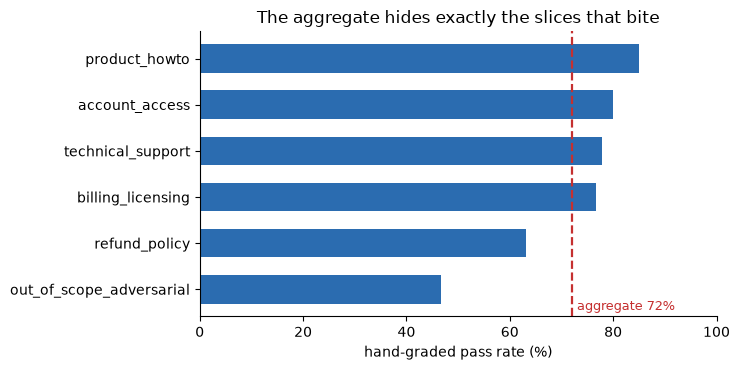

weakest slice: out_of_scope_adversarial at 46.7% (7 of 15)
Nobody argued with the number: every verdict traces to a named
criterion applied to a preserved case, on a sheet anyone can re-derive.


In [21]:
plot = slice_rates.sort_values("rate")
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.barh(plot.index, plot["rate"], color="#2B6CB0", height=0.62)
ax.axvline(rate, color="#C53030", lw=1.6, ls="--")
ax.text(rate + 1, -0.45, f"aggregate {rate}%", color="#C53030", fontsize=9)
ax.set_xlim(0, 100); ax.set_xlabel("hand-graded pass rate (%)")
ax.set_title("The aggregate hides exactly the slices that bite")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout(); plt.show()

worst = plot.index[0]
print(f"weakest slice: {worst} at {plot.loc[worst, 'rate']}% "
      f"({int(plot.loc[worst, 'sum'])} of {int(plot.loc[worst, 'count'])})")
print("Nobody argued with the number: every verdict traces to a named")
print("criterion applied to a preserved case, on a sheet anyone can re-derive.")

The number redefined the demo in retrospect. The demo was not false; it was
a biased sample drawn from the strongest slice, and the golden dataset is
the corrected sample. One last piece of arithmetic puts the number in the
book's larger frame: reliability compounds against you, which is why the
last percentage points are the expensive ones, and why an honestly measured
pass rate is a starting point rather than a final verdict.

In [22]:
per_interaction = 0.99
n = 100
p_clean = per_interaction ** n
print(f"a system passing {per_interaction:.0%} of interactions goes "
      f"{n} interactions without a failure only {p_clean:.0%} of the time")
print(f"probability of at least one failure in {n}: {1 - p_clean:.0%}")

a system passing 99% of interactions goes 100 interactions without a failure only 37% of the time
probability of at least one failure in 100: 63%


## Case File: Renderloft

From this chapter on, each chapter of the book closes with a short ledger
recording where the running system stands. The cell below prints the first
one, and every figure in it comes from the canon dictionary and the
committed grade sheet, never from prose.

In [23]:
adversarial = slice_rates.loc["out_of_scope_adversarial"]
print(f"""
CASE FILE
  Clock:        week {CANON['WEEK']} after the ${CANON['ANNUAL_PRICE_USD']:,} refund incident
  System:       golden dataset v{CANON['DATASET_VERSION']} in the repository:
                {CANON['GOLDEN_CASES']} cases, {len(CATEGORIES)} intent categories,
                hash-manifested and reviewed like code
  The number:   pass rate measured for the first time: {rate}%
                ({passes} of {total}; the demo had felt like ~{CANON['DEMO_FELT_LIKE_PCT']}%)
                adversarial slice: {int(adversarial['sum'])} of {int(adversarial['count'])}
  New artifact: golden_0047, the incident preserved as a permanent test case,
                plus the C1-C6 rubric with calibration pairs
  Open risk:    two people, {CANON['GRADING_AFTERNOONS']} afternoons, one grading
                pass. Hand-grading does not scale, and it does not run in CI.
                Chapter 4 builds the judge.
""")


CASE FILE
  Clock:        week 6 after the $4,200 refund incident
  System:       golden dataset v1.0.0 in the repository:
                150 cases, 6 intent categories,
                hash-manifested and reviewed like code
  The number:   pass rate measured for the first time: 72%
                (108 of 150; the demo had felt like ~95%)
                adversarial slice: 7 of 15
  New artifact: golden_0047, the incident preserved as a permanent test case,
                plus the C1-C6 rubric with calibration pairs
  Open risk:    two people, 3 afternoons, one grading
                pass. Hand-grading does not scale, and it does not run in CI.
                Chapter 4 builds the judge.



## Summary

The chapter's working thesis fits in one sentence: **your evaluation dataset
is your specification.** Before the golden file existed, the team's
definition of correct lived in scattered heads and surfaced only during
arguments; now it is a reviewable, versioned artifact, and disagreements
about quality become pull requests instead of meetings.

If the dataset is the spec, two of its properties matter more than its size.
The first is honesty of sourcing: cases mined from production and from
incidents, over-weighted toward the categories with the highest cost of
failure, because a dataset drawn from your hopes will certify your hopes.
The second is freshness: golden answers encode the business, the business
changes, and a stale case does active damage by failing correct behavior
until nobody believes a red result.

The profile discipline holds at every scale: one blended score hid a failing
safety axis in a single answer, and the aggregate pass rate hid an
adversarial slice failing more often than it passed. Slices, not averages,
tell you where to dig.

What this chapter deliberately did not solve is the cost of judgment. Half
the rubric is deterministic and free forever; the other half took two senior
people three afternoons of hand-grading, and that price is why the next
chapter builds an automated judge, calibrated against human verdicts and
trusted only as far as its calibration earns.

### Exercises

1. **Reflection.** Pick one AI feature you own or use daily and write its
   `GoldenExample` for a single hard input, including three rubric criteria
   with a pass example and a fail example each. Which criterion was hardest
   to make observable rather than a matter of taste?

2. **Application.** `data/tickets_raw.jsonl` contains the raw, unlabeled
   ticket corpus this chapter mined. Curate a 20-case golden dataset from
   it: happy path, ambiguous, out-of-scope, and at least one adversarial
   input, each tagged with an intent category and a risk tier, each with a
   rationale. Compare your category allocation against the census printed
   in Act III and defend the differences.

3. **Discussion.** With a colleague, independently double-grade ten outputs
   from any AI system you both use, against a rubric you write together
   first. Count your disagreements and classify each one: ambiguous rubric
   wording, missing calibration example, or a genuine judgment call. What
   does the remainder tell you about which criteria will need a calibrated
   judge rather than a sharper sentence?

### The hand-off

Right now we are defining the target. In the next chapter, we build the
machine that grades against it.